In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [2]:
diabetes_train_resamples = pd.read_csv("datasets/diabetes_train_resamples.csv")
diabetes_test = pd.read_csv("datasets/diabetes_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [3]:
X_train = diabetes_train_resamples.drop('Outcome', axis = 1)
X_test = diabetes_test.drop('Outcome', axis = 1)
y_train = diabetes_train_resamples['Outcome']
y_test = diabetes_test['Outcome']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [4]:
#Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To ch

### Prediction and utility

In [5]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)


Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------


---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
          Predicted 0  Predicted 1
Actual 0           70           29
Actual 1           16           39


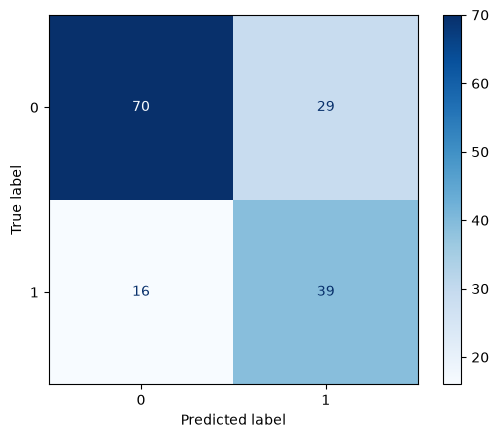

Saved results to results/model_results_diabetes.xlsx


In [6]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original_oversampled",
    epsilon=0,
    output_file="results/model_results_diabetes.xlsx"
)


In [7]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=5, bivariate = True)

Accuracy: 0.7506
Precision: 0.7593
Recall: 0.7333
F1 Score: 0.7455
Time: 0.16435909271240234


{'fit_time': array([0.01224518, 0.00957441, 0.00813389, 0.00598121, 0.01053715]),
 'score_time': array([0.02419686, 0.01665092, 0.0240097 , 0.02531147, 0.0205934 ]),
 'test_accuracy': array([0.76397516, 0.72670807, 0.725     , 0.73125   , 0.80625   ]),
 'test_precision': array([0.76923077, 0.75342466, 0.725     , 0.75342466, 0.79518072]),
 'test_recall': array([0.75      , 0.67901235, 0.725     , 0.6875    , 0.825     ]),
 'test_f1': array([0.75949367, 0.71428571, 0.725     , 0.71895425, 0.80981595])}

In [8]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=5, bivariate = True, perturbation_type="Original_hpt_oversampled",
        epsilon=0, output_file="results/model_results_diabetes.xlsx")

Best parameters: {'C': 0.1}
Accuracy : 0.7568
Precision: 0.7682
Recall   : 0.7357
F1 Score : 0.7511
Time     : 9.18 s


(LogisticRegression(C=0.1), {'C': 0.1})

----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [9]:
# Define ranges
ranges = [[0,20], [40,300], [30,200], [5,100], [2,900], [10,70], [0,3], [21,100]]
print(ranges)
sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

# sensitivity = []
# for col in X_train.columns:
#     lower = X_train[col].quantile(0.01)
#     upper = X_train[col].quantile(0.99)

#     sensitivity.append(upper-lower)
# print(sensitivity)

[[0, 20], [40, 300], [30, 200], [5, 100], [2, 900], [10, 70], [0, 3], [21, 100]]
[20, 260, 170, 95, 898, 60, 3, 79]


In [10]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))
        #X_train_perturbed[var] = X_train[var] + noise

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [11]:
for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input_oversampled",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt_oversampled",
        epsilon=e, output_file="results/model_results_diabetes.xlsx")


Training set: 
---------------------------------------
Accuracy: 0.5461
Precision: 0.5468
Recall: 0.5387
F1 Score: 0.5427
---------------------------------------
---------------------------------------
Accuracy: 0.3636
Precision: 0.2471
Recall: 0.3818
F1 Score: 0.3000
---------------------------------------


Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5088
Precision: 0.5103
Recall   : 0.4964
F1 Score : 0.5017
Time     : 0.25 s
Training set: 
---------------------------------------
Accuracy: 0.5511
Precision: 0.5571
Recall: 0.4988
F1 Score: 0.5263
---------------------------------------
---------------------------------------
Accuracy: 0.6623
Precision: 0.8000
Recall: 0.0727
F1 Score: 0.1333
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5236
Precision: 0.5241
Recall   : 0.4809
F1 Score : 0.4989
Time     : 0.36 s
Training set: 
---------------------------------------
Accuracy: 0.6496
Precision: 0.6571
Recall: 0.6259
F1 Score: 0.6411
---------------------------------------
---------------------------------------
Accuracy: 0.7792
Precision: 0.7059
Recall: 0.6545
F1 Score: 0.6792
---------------------------------------
Saved results to results/model_results

----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [12]:
n = X_train.shape[0]
C_x = np.max(np.linalg.norm(X_train_sc, axis=1))
lambda_reg = 1 / model.C
sensitivity = (C_x*2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity/e, size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity /e, size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [13]:
for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output_oversampled",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

Training set: 
---------------------------------------
Accuracy: 0.7294
Precision: 0.7514
Recall: 0.6858
F1 Score: 0.7171
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5758
Recall: 0.6909
F1 Score: 0.6281
---------------------------------------


Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7618
Precision: 0.7679
Recall: 0.7506
F1 Score: 0.7591
---------------------------------------
---------------------------------------
Accuracy: 0.7013
Precision: 0.5652
Recall: 0.7091
F1 Score: 0.6290
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Prec

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [14]:
# data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
# print("data_norm :", data_norm) #(max L2 norm of a scaled training row)

In [15]:
# epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]

# internal_models = fc.internal_perturbation_save_results(
#     X_train_sc,
#     y_train,
#     X_test_sc,
#     y_test,
#     epsilon_values=epsilon_values,
#     data_norm=data_norm,
#     C=model.C,
#     bivariate=True,
#     output_file="results/model_results_diabetes.xlsx",
#     perturbation_type="Internal_oversampled"
# )
